In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [21]:
## now load the iris dataset
data=sns.load_dataset("iris")

In [22]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [23]:
data.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [25]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [26]:
data.duplicated().sum()

np.int64(1)

In [27]:
## as there is 1 duplicate row, we will drop it
data.drop_duplicates(inplace=True)

In [28]:
data.duplicated().sum()

np.int64(0)

In [29]:
##lets see the classification of species
data['species'].value_counts()

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

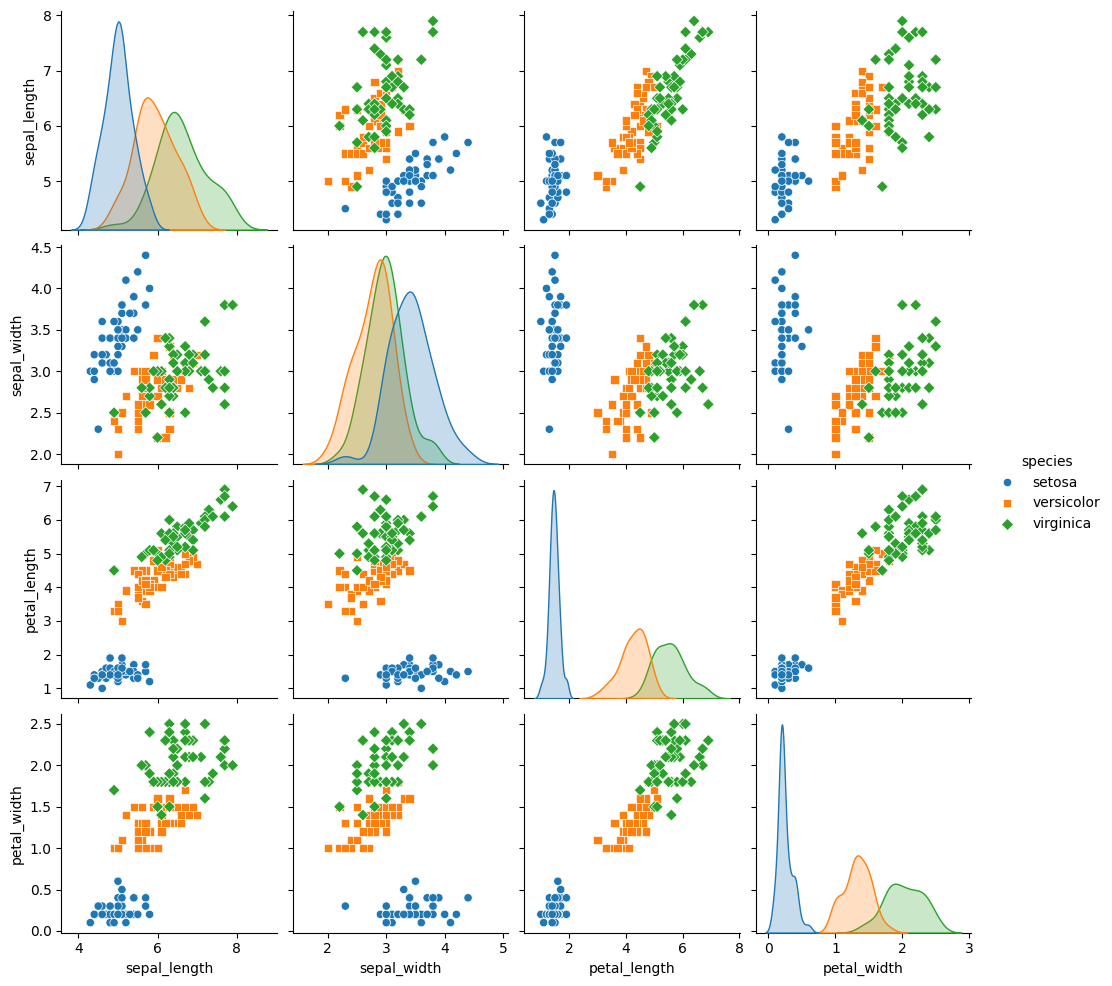

In [30]:
## lets visualize the data
sns.pairplot(data, hue='species', markers=["o", "s", "D"])


In [31]:
## after visualizing the data, we can see that the species are separable
## lets split the data into features and target variable
x = data.drop('species', axis=1)
y = data['species']

###### When we split data into training and testing sets, stratify=y keeps the same ratio of classes (like flower species) in both sets.

###### It will preserve the same ratio as the original:
###### Now both train and test sets have a fair distribution of each species.



In [37]:
## after split targer and features, lets split the data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [38]:
## Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [39]:
## train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [40]:
## predict the species for the test set
y_pred = knn_model.predict(x_test)

In [ ]:
## evaluate the model accuracy, confusion matrix and classification report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.93
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



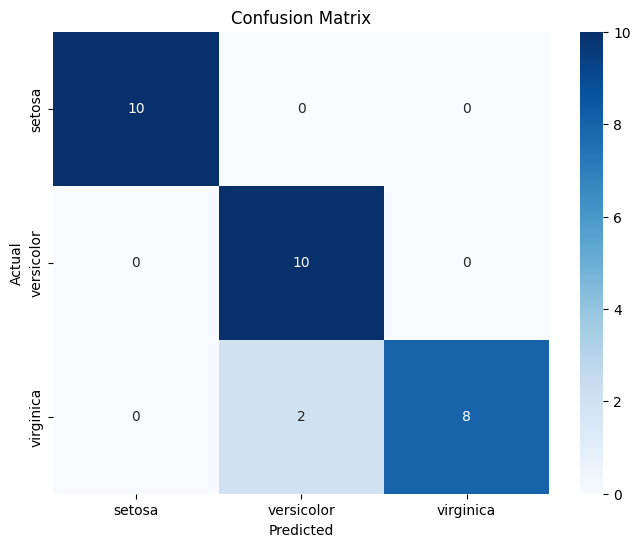

In [42]:
## lets visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=data['species'].unique(), yticklabels=data['species'].unique())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [43]:
## lets precdict the species for a new sample
new_sample = np.array([[5.0, 3.5, 1.5, 0.2]])  # Example features
new_sample_scaled = scaler.transform(new_sample)
predicted_species = knn_model.predict(new_sample_scaled)
print(f"Predicted species for the new sample: {predicted_species[0]}")

Predicted species for the new sample: setosa


d:\MachineLearning(ExtraProject)\Iris-Classification-using-KNN\.virisknn\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


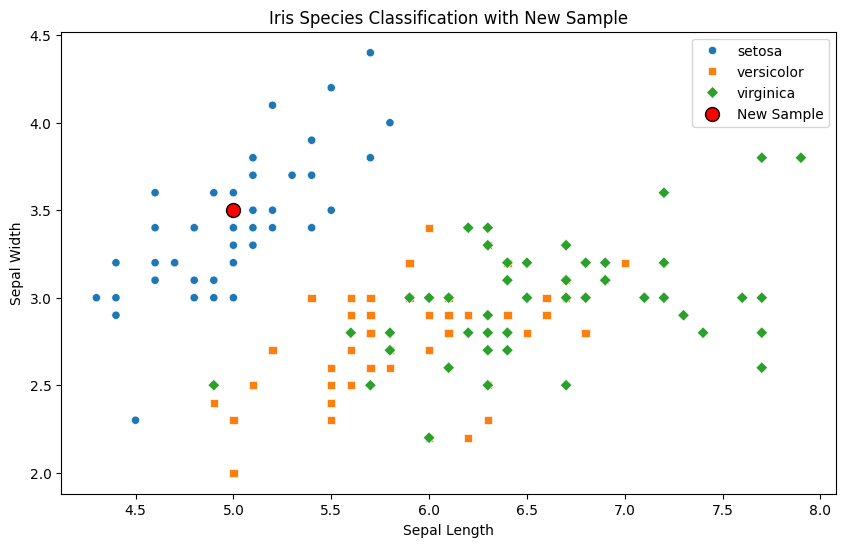

In [ ]:
## lets visualize the above sample in the feature space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['sepal_length'], y=data['sepal_width'], hue=data['species'], style=data['species'], markers=["o", "s", "D"])
plt.scatter(new_sample[0][0], new_sample[0][1], color='red', s=100, label='New Sample', edgecolor='black')
plt.title('Iris Species Classification with New Sample')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')       
plt.legend()
plt.show()


In [46]:
## lets check on above real sample
real_sample = np.array([[6.7, 3.1, 5.6, 2.4]])  # Example features
real_sample_scaled = scaler.transform(real_sample)
predicted_real_species = knn_model.predict(real_sample_scaled)
print(f"Predicted species for the real sample: {predicted_real_species[0]}")

Predicted species for the real sample: virginica


d:\MachineLearning(ExtraProject)\Iris-Classification-using-KNN\.virisknn\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


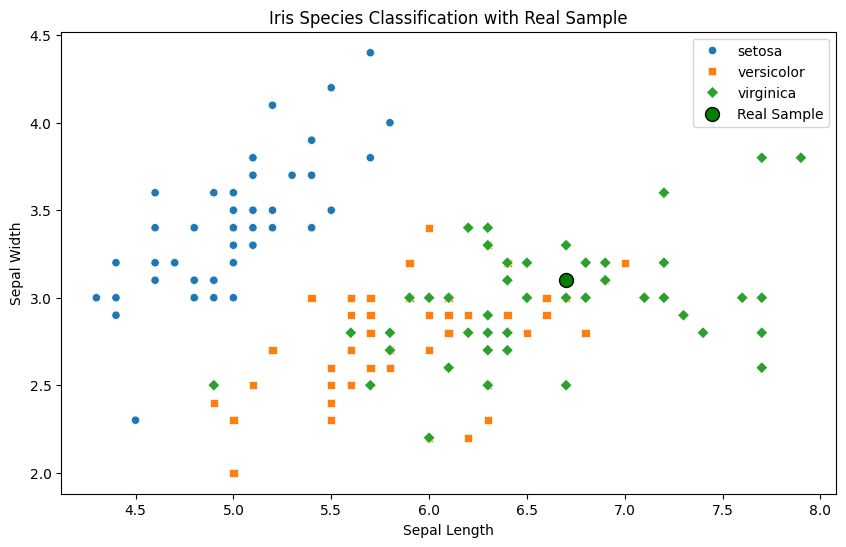

In [47]:
## lets visualize the above real sample in the feature space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['sepal_length'], y=data['sepal_width'], hue=data['species'], style=data['species'], markers=["o", "s", "D"])
plt.scatter(real_sample[0][0], real_sample[0][1], color='green', s=100, label='Real Sample', edgecolor='black') 
plt.title('Iris Species Classification with Real Sample')
plt.xlabel('Sepal Length')  
plt.ylabel('Sepal Width')
plt.legend()
plt.show() 



In [49]:
## lets prodoct 
real_sample = np.array([[6.2, 3.4, 5.4, 2.3]])  # Example features
real_sample_scaled = scaler.transform(real_sample)
predicted_real_species = knn_model.predict(real_sample_scaled)
print(f"Predicted species for the real sample: {predicted_real_species[0]}")

Predicted species for the real sample: virginica


d:\MachineLearning(ExtraProject)\Iris-Classification-using-KNN\.virisknn\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [50]:
## lets save the model using pickle
import pickle
with open('knn_iris_model.pkl', 'wb') as file:
    pickle.dump(knn_model, file)


In [51]:
# Save the scaler as well
with open('scaler_iris.pkl', 'wb') as file:
    pickle.dump(scaler, file)